In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
base_model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
base_model.fit(X_train, y_train)
proba_uncalibrated = base_model.predict_proba(X_test)[:, 1]

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
base_model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
base_model.fit(X_train, y_train)
proba_uncalibrated = base_model.predict_proba(X_test)[:, 1]
print("Base model trained.")

Base model trained.


In [11]:
calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)
proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
print("Calibration complete.")

Calibration complete.


In [12]:
print("Uncalibrated score distribution:")
print(pd.Series(proba_uncalibrated).describe())
print(f"\nScores > 0.5: {(proba_uncalibrated > 0.5).sum()}")
print(f"Scores > 0.9: {(proba_uncalibrated > 0.9).sum()}")

print("\nCalibrated score distribution:")
print(pd.Series(proba_calibrated).describe())
print(f"\nScores > 0.5: {(proba_calibrated > 0.5).sum()}")
print(f"Scores > 0.9: {(proba_calibrated > 0.9).sum()}")

Uncalibrated score distribution:
count    5.696200e+04
mean     1.707128e-03
std      3.993455e-02
min      1.578666e-09
25%      3.107467e-07
50%      9.931441e-07
75%      3.623275e-06
max      9.999999e-01
dtype: float64

Scores > 0.5: 93
Scores > 0.9: 89

Calibrated score distribution:
count    56962.000000
mean         0.001800
std          0.036913
min          0.000047
25%          0.000060
50%          0.000096
75%          0.000172
max          1.000000
dtype: float64

Scores > 0.5: 86
Scores > 0.9: 72


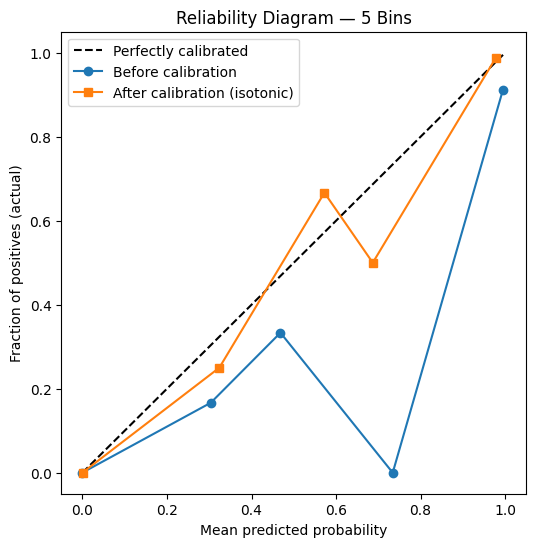

In [13]:
prob_true5, prob_pred5 = calibration_curve(y_test, proba_uncalibrated, n_bins=5, strategy='uniform')
prob_true_cal5, prob_pred_cal5 = calibration_curve(y_test, proba_calibrated, n_bins=5, strategy='uniform')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(prob_pred5, prob_true5, marker='o', label='Before calibration')
plt.plot(prob_pred_cal5, prob_true_cal5, marker='s', label='After calibration (isotonic)')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (actual)')
plt.title('Reliability Diagram — 5 Bins')
plt.legend()
plt.savefig("../outputs/05_reliability_5bins.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.metrics import average_precision_score

print(f"AUPRC before calibration: {average_precision_score(y_test, proba_uncalibrated):.4f}")
print(f"AUPRC after calibration:  {average_precision_score(y_test, proba_calibrated):.4f}")

AUPRC before calibration: 0.8791
AUPRC after calibration:  0.8772


In [15]:
def total_cost(y_true, y_proba, threshold, cost_fn=10, cost_fp=1):
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return cost_fn * fn + cost_fp * fp, fn, fp

thresholds = np.arange(0.01, 1.0, 0.01)
costs_cal = [total_cost(y_test, proba_calibrated, t)[0] for t in thresholds]
best_idx = np.argmin(costs_cal)
best_t_cal = thresholds[best_idx]
cost_cal, fn_cal, fp_cal = total_cost(y_test, proba_calibrated, best_t_cal)

print(f"Optimal threshold (calibrated): {best_t_cal:.2f}")
print(f"At this threshold: {fn_cal} missed frauds, {fp_cal} false alarms, cost={cost_cal}")

Optimal threshold (calibrated): 0.08
At this threshold: 13 missed frauds, 19 false alarms, cost=149


In [16]:
import numpy as np

bin_edges = np.linspace(0, 1, 6)  # 5 bins
bin_indices = np.digitize(proba_uncalibrated, bin_edges) - 1
for i in range(5):
    mask = bin_indices == i
    n_total = mask.sum()
    n_fraud = y_test[mask].sum()
    print(f"Bin {i} ({bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}): {n_total} transactions, {n_fraud} fraud")

Bin 0 (0.0-0.2): 56861 transactions, 15 fraud
Bin 1 (0.2-0.4): 6 transactions, 1 fraud
Bin 2 (0.4-0.6): 3 transactions, 1 fraud
Bin 3 (0.6-0.8): 3 transactions, 0 fraud
Bin 4 (0.8-1.0): 89 transactions, 81 fraud
